# SCS 3546: Deep Learning
> **Assignment 4: Generative Models**

### Your name & student number:

<pre> Megan Da Costa </pre>

<pre> qq586611 </pre>

## **Assignment Description**
***

In this assignment, you are generating sample images with a deep convolutional Variational Autoencoder


# Data
***
Generate data by using the following command


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def create_enhanced_3d_shapes(num_samples=8000, img_size=64):
    """Enhanced 3D shapes with better quality"""
    images = []

    # Pre-defined color schemes
    room_schemes = [
        (np.array([0.9, 0.95, 1.0]), np.array([0.4, 0.5, 0.6])),  # Blue
        (np.array([1.0, 0.98, 0.95]), np.array([0.6, 0.5, 0.4])), # Warm
        (np.array([0.95, 1.0, 0.98]), np.array([0.5, 0.6, 0.4])), # Green
    ]

    obj_colors = np.array([
        [0.95, 0.3, 0.2],  # Red
        [0.2, 0.95, 0.3],  # Green
        [0.2, 0.4, 0.95],  # Blue
        [0.95, 0.85, 0.1], # Yellow
        [0.8, 0.2, 0.95],  # Purple
        [0.1, 0.95, 0.95], # Cyan
    ])

    for i in range(num_samples):
        img = np.zeros((img_size, img_size, 3))

        # Select colors
        wall_color, floor_color = room_schemes[np.random.randint(len(room_schemes))]
        obj_color = obj_colors[np.random.randint(len(obj_colors))]
        shape_type = np.random.choice(['sphere', 'cube', 'cylinder'])

        # Create room with gradient
        floor_level = img_size * 2 // 3

        # Wall gradient
        for y in range(floor_level):
            factor = 0.7 + 0.3 * (y / floor_level)
            img[y, :] = wall_color * factor

        # Floor gradient
        for y in range(floor_level, img_size):
            factor = 0.6 + 0.4 * ((y - floor_level) / (img_size - floor_level))
            img[y, :] = floor_color * factor

        # Object parameters
        obj_size = np.random.randint(20, 35)
        pos_x = np.random.randint(30, img_size - 30)
        pos_y = floor_level - obj_size // 2

        if shape_type == 'sphere':
            # Enhanced sphere with lighting
            y_arr, x_arr = np.indices((img_size, img_size))
            dist_sq = (x_arr - pos_x)**2 + (y_arr - pos_y)**2
            radius = obj_size // 2
            sphere_mask = dist_sq <= radius**2

            if np.any(sphere_mask):
                # Simple lighting
                dist = np.sqrt(dist_sq[sphere_mask])
                lighting = 0.4 + 0.6 * (1 - dist / radius)
                sphere_y, sphere_x = np.where(sphere_mask)
                img[sphere_y, sphere_x] = obj_color * lighting[:, np.newaxis]

                # Highlight
                highlight_mask = (x_arr - pos_x + radius//3)**2 + (y_arr - pos_y + radius//3)**2 <= (radius//4)**2
                img[highlight_mask] = np.clip(obj_color * 1.3, 0, 1)

        elif shape_type == 'cube':
            # Enhanced cube
            half = obj_size // 2

            # Front face
            img[pos_y-half:pos_y+half, pos_x-half:pos_x+half] = obj_color

            # Right side
            img[pos_y-half:pos_y+half, pos_x+half:pos_x+half+half//2] = obj_color * 0.7

            # Top side
            img[pos_y-half-half//3:pos_y-half, pos_x-half:pos_x+half+half//2] = obj_color * 1.1

        elif shape_type == 'cylinder':
            # Enhanced cylinder
            radius = obj_size // 3
            height = obj_size

            # Body
            img[pos_y-height//2:pos_y+height//2, pos_x-radius:pos_x+radius] = obj_color * 0.8

            # Top
            y_arr, x_arr = np.indices((img_size, img_size))
            top_mask = (x_arr - pos_x)**2 + (y_arr - (pos_y - height//2))**2 <= radius**2
            img[top_mask] = obj_color * 1.1

            # Bottom
            bottom_mask = (x_arr - pos_x)**2 + (y_arr - (pos_y + height//2))**2 <= radius**2
            img[bottom_mask] = obj_color * 0.6

        images.append(np.clip(img, 0, 1))

    return np.array(images)

#

print("Creating enhanced 3D shapes dataset...")
x_train = create_enhanced_3d_shapes(10000, 64)

Creating enhanced 3D shapes dataset...


### Visualize

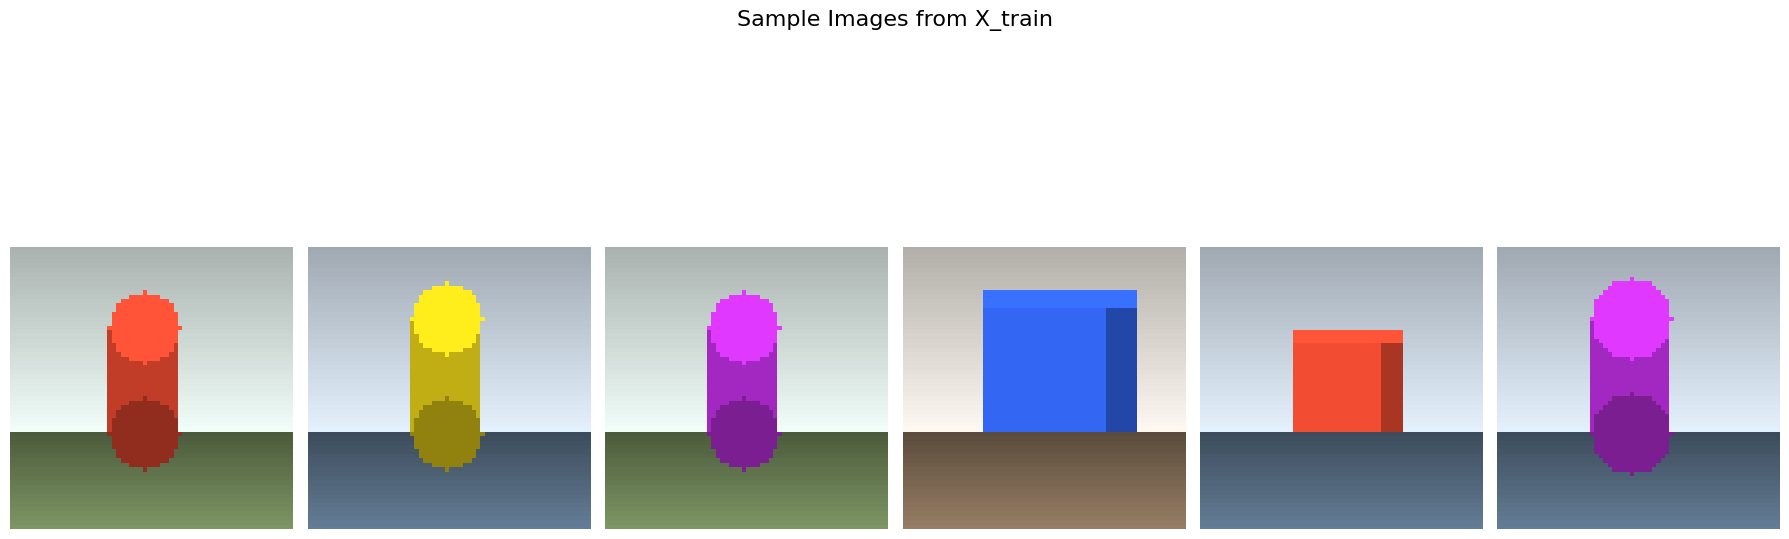

In [2]:
# Show samples from X_train
fig, axes = plt.subplots(1, 6, figsize=(18, 8))

for i in range(6):
    axes[i].imshow(x_train[i])
    axes[i].axis('off')

plt.suptitle('Sample Images from X_train', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

### Convolutional Variational Autoencoder

In [3]:
#Build a Convolutional Variational Autoencoder with four layers and a coding size of 2. You can find a sample architecture https://www.tensorflow.org/tutorials/generative/cvae#network_architecture

import tensorflow as tf

#ENCODER
coding_size = 2

encoder_input = tf.keras.Input(shape=(64, 64, 3))

conv1 = tf.keras.layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_input)
conv2 = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(conv1)
conv3 = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(conv2)
conv4 = tf.keras.layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(conv3)

flattened = tf.keras.layers.Flatten()(conv4)
encoder_output = tf.keras.layers.Dense(128, activation="relu")(flattened)

z_mean = tf.keras.layers.Dense(coding_size, name="z_mean")(encoder_output)
z_log_var = tf.keras.layers.Dense(coding_size, name="z_log_var")(encoder_output)

In [20]:
#BOTTLENECK
# sampling function for latent layer
def sampling(args):
    z_mean, z_log_var = args
    # epsilon in simple normal distribution
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], coding_size))
    return z_mean + tf.exp(z_log_var) * epsilon

z = tf.keras.layers.Lambda(sampling, output_shape=(coding_size,))([z_mean, z_log_var])

In [7]:
#DECODER

latent_input = tf.keras.Input(shape=(coding_size,))

decoder_input = tf.keras.layers.Dense(4 * 4 * 256, activation="relu")(latent_input)
reshape = tf.keras.layers.Reshape((4, 4, 256))(decoder_input)

dconv1 = tf.keras.layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(reshape)
dconv2 = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(dconv1)
dconv3 = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(dconv2)
dconv4 = tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu")(dconv3)

decoder_outputs = tf.keras.layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(dconv4)

### Train Model
Train your model with gradient tape and feed input and output.

In [9]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [21]:
encoder_model = tf.keras.Model(inputs=encoder_input, outputs=[z_mean, z_log_var, z])
decoder_model = tf.keras.Model(inputs=latent_input, outputs=decoder_outputs)

vae = VAE(encoder_model, decoder_model)
vae.compile(optimizer=tf.keras.optimizers.Adam())

#Train it with the data
vae.fit(x_train, batch_size=64)

157/157 ━━━━━━━━━━━━━━━━━━━━ 89s 532ms/step - kl_loss: 0.6972 - loss: 2527.5112 - reconstruction_loss: 2526.8145


### 2D Render

In [ ]:
# def plot_latent_images(model, n, digit_size=28):
#   """Plots n x n digit images decoded from the latent space."""

#   norm = tfp.distributions.Normal(0, 1)
#   grid_x = norm.quantile(np.linspace(0.05, 0.95, n))
#   grid_y = norm.quantile(np.linspace(0.05, 0.95, n))
#   image_width = digit_size*n
#   image_height = image_width
#   image = np.zeros((image_height, image_width))

#   for i, yi in enumerate(grid_x):
#     for j, xi in enumerate(grid_y):
#       z = np.array([[xi, yi]])
#       x_decoded = model.sample(z)
#       digit = tf.reshape(x_decoded[0], (digit_size, digit_size))
#       image[i * digit_size: (i + 1) * digit_size,
#             j * digit_size: (j + 1) * digit_size] = digit.numpy()

#   plt.figure(figsize=(10, 10))
#   plt.imshow(image, cmap='Greys_r')
#   plt.axis('Off')
#   plt.show()

#   plot_latent_images(vae, 20)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━

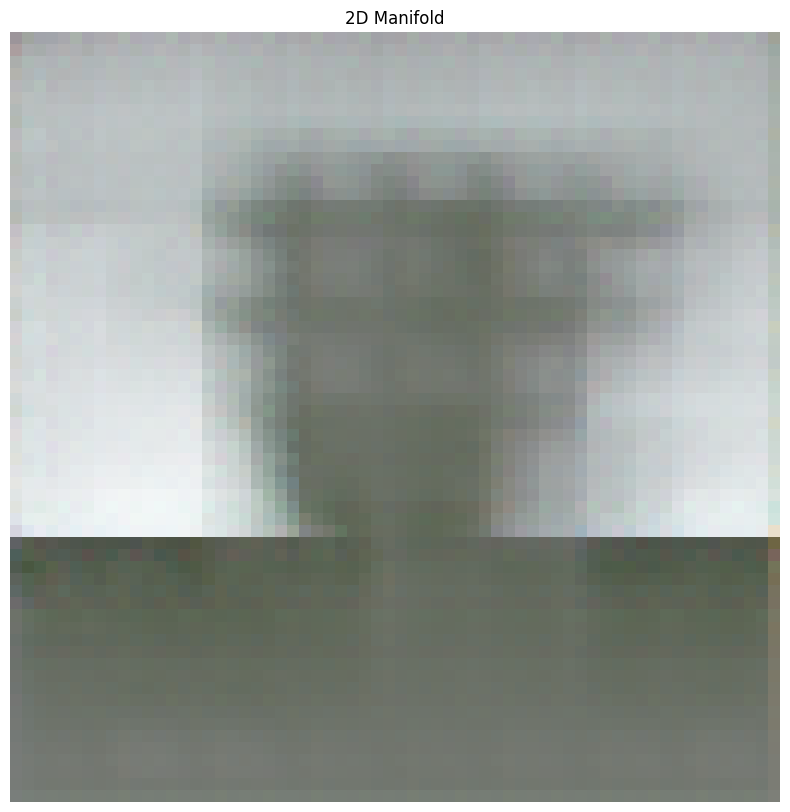

In [31]:
import numpy as np
import matplotlib.pyplot as plt

n = 15
grid_x = np.linspace(0.05, 0.95, n)
grid_y = np.linspace(0.05, 0.95, n)

image = np.zeros((64 * n, 64 * n, 3))

for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z = np.array([[xi, yi]])
        x_decoded = decoder_model.predict(z)
        images = x_decoded[0]

        image[i * 64: (i + 1) * 64,
              j * 64: (j + 1) * 64] = images

plt.figure(figsize=(10, 10))
plt.imshow(images)
plt.axis("off")
plt.title("2D Manifold")
plt.show()